# Import des données issues de la base SIRENE pour les établissements du lien social

Bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Import des données

Définition des catégories d'établissements à importer

In [3]:
code_etab = [
    # 55.1A (avec resto), 55.1C (sans resto), 55.1D (préfecture), 55.1E (auberges) sont devenus 55.10Z
    "55.10Z", "55.1A", "55.1C", "55.1D", "55.1E", 
    
    # 55.2C est devenu 55.30Z
    "55.30Z", "55.2C",
    
    # 55.3A est devenu 56.10A
    "56.10A", "55.3A",
    
    # 55.4A (Cafés tabacs) et 55.4B (Débits de boissons) sont devenus 56.30Z
    "56.30Z", "55.4A", "55.4B", 
    
    # 52.4L (livres) est devenu 47.61Z
    "47.61Z", "52.4L",
    
    # 52.4R (presse/papeterie) est devenu 47.62Z
    "47.62Z", "52.4R",
    
    # 92.3A (Activités artistiques) est devenu principalement 90.01Z
    "90.01Z", "92.3A", 
    
    # 92.3B est devenu 90.02Z
    "90.02Z", "92.3B",
    
    # 92.3D est devenu 90.04Z
    "90.04Z", "92.3D",
    
    # 90.03A et 90.03B (Création) n'avaient pas de code propre en 2003 (ils étaient noyés dans le 92.3A)
    "90.03A", "90.03B", 
    
    # 92.3H et 92.7C sont devenus 93.29Z
    "93.29Z", "92.3H", "92.7C",
    
    # 85.3K est devenu 88.10A
    "88.10A", "85.3K",
    
    # 91.3E est devenu 94.99Z
    "94.99Z", "91.3E"
]

Import des données brutes

In [4]:
chunks = []
# 1. On force le type 'str' (texte) pour éviter que Pandas supprime les zéros du début
types_dict = {
    'siret': str,
    'codeCommuneEtablissement': str,
    'codeCommune2Etablissement': str,
    'activitePrincipaleEtablissement': str,
    'etatAdministratifEtablissement': str,
    'trancheEffectifsEtablissement' : str,
}
print("Lecture du fichier par blocs en cours...")
# 2. Lecture par chunks
for chunk in pd.read_csv(
    r"C:\Users\yancr\Downloads\StockEtablissement_utf8\StockEtablissement_utf8.csv", 
    chunksize=100000, 
    usecols=[
        'activitePrincipaleEtablissement',
        'codeCommuneEtablissement', 'dateCreationEtablissement',
        'siret', 'etatAdministratifEtablissement', 'dateDebut','trancheEffectifsEtablissement'
    ],
    dtype=types_dict
):
    # Filtre sur les codes d'activité souhaités
    chunk_filtre = chunk[chunk['activitePrincipaleEtablissement'].isin(code_etab)]
    chunks.append(chunk_filtre)

# 3. On recolle les morceaux à la fin
df = pd.concat(chunks, ignore_index=True)
print(f"Terminé ! Nombre d'établissements conservés : {len(df)}")

Lecture du fichier par blocs en cours...
Terminé ! Nombre d'établissements conservés : 3148146


## Traitement des données manquantes

### 1 Gestion des établissements fermés sans date indiquées

On commence par regarder combien d'établissements sont concernés.

In [5]:
df.loc[(df['dateDebut'].isna()) & (df['etatAdministratifEtablissement'] == 'F')].count()

siret                              1379
dateCreationEtablissement             1
trancheEffectifsEtablissement      1379
codeCommuneEtablissement           1378
dateDebut                             0
etatAdministratifEtablissement     1379
activitePrincipaleEtablissement    1379
dtype: int64

On enleve ces établissements

In [6]:
df = df[
    ~(
        (df['dateDebut'].isna()) &
        (df['etatAdministratifEtablissement'] == 'F')
    )
]

print(f"Terminé ! Nombre d'établissements conservés : {len(df)}")

Terminé ! Nombre d'établissements conservés : 3146767


### 2 Gestion des établissements fermés manuellement

Nombre des établissements fermés au 1er janvier de chaque année 

In [7]:
for annee in range(2002, 2023):
    # On filtre les lignes et on compte leur nombre avec len()
    nb_etablissements = len(df[(df['dateDebut'] == f'{annee}-01-01') & (df['etatAdministratifEtablissement'] == 'F')])
    
    print(f"{annee} : {nb_etablissements}")

2002 : 1982
2003 : 1789
2004 : 2195
2005 : 2423
2006 : 2056
2007 : 1779
2008 : 32430
2009 : 2280
2010 : 2513
2011 : 2355
2012 : 2094
2013 : 1988
2014 : 2091
2015 : 1965
2016 : 2383
2017 : 2408
2018 : 1925
2019 : 2188
2020 : 2119
2021 : 1616
2022 : 1925


### 3 Exploration de la construction des données

Cette partie va permettre de justifier la création d'un de données SIRENE annuelle uniquement. En effet, on notera que les fermetures d'établissements contiennent des discontinuités à certaines périodes : en toute fin ou tout début d'années, à chaque fin de trimestre ainsi qu'en début, milieu et fin de mois.

Graphique montrant l'évolution du nombre de fermetures en fonction du jour du mois entre 2002 et 2022

<Axes: title={'center': 'Répartition administrative des fermetures'}, xlabel='jour_du_mois'>

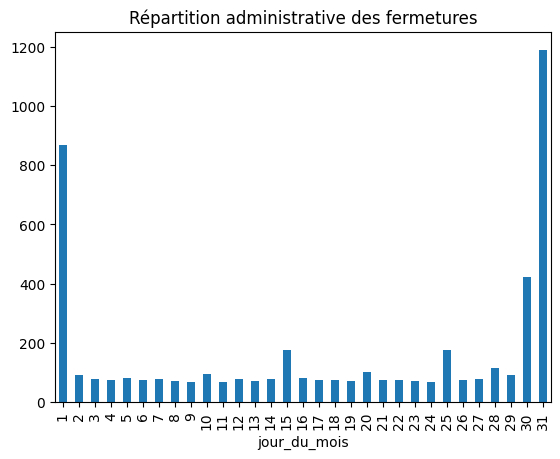

In [8]:
# 1. Préparation des dates
df['dateDebut'] = pd.to_datetime(df['dateDebut'], errors='coerce')

# 2. Filtrage global (2002 à 2022 + Fermetures)
df_periode = df[
    (df['dateDebut'].dt.year >= 2002) & 
    (df['dateDebut'].dt.year <= 2022) & 
    (df['etatAdministratifEtablissement'] == 'F')
].copy()

# 3. Extraction du jour du mois
df_periode['jour_du_mois'] = df_periode['dateDebut'].dt.day

# 4. Calcul en deux étapes pour une moyenne rigoureuse :
# Étape A : On compte les fermetures pour chaque date réelle (ex: combien le 01/01/2007, le 01/02/2007...)
comptage_par_date = df_periode.groupby(['dateDebut', 'jour_du_mois']).size().reset_index(name='nb')

# Étape B : On fait la moyenne par rang de jour (Moyenne de tous les "1er", tous les "2", etc.)
moyenne_globale = comptage_par_date.groupby('jour_du_mois')['nb'].mean()

# 5. visualisation
moyenne_globale.plot(kind='bar', title='Répartition administrative des fermetures')

Graphique montrant l'évolution du nombre de fermetures la dernière semaine du mois, en fonction du mois, entre 2002 et 2022

<Axes: title={'center': 'Nombre moyen de fermetures la dernière semaine du mois (2002-2022)'}>

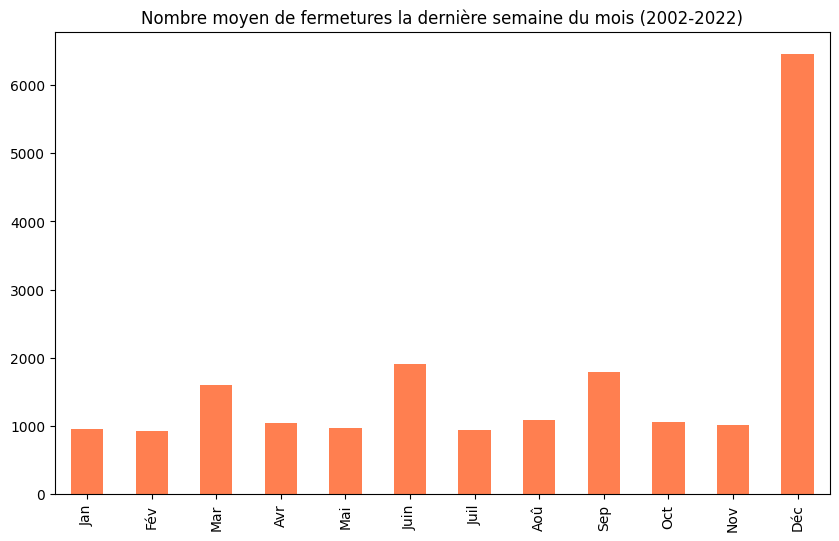

In [9]:
# 1. Préparation des dates
df['dateDebut'] = pd.to_datetime(df['dateDebut'], errors='coerce')

# 2. Filtrage global (2002 à 2022 + Fermetures uniquement)
df_periode = df[
    (df['dateDebut'].dt.year >= 2002) & 
    (df['dateDebut'].dt.year <= 2022) & 
    (df['etatAdministratifEtablissement'] == 'F')
].copy()

# 3. Filtrage de la dernière semaine du mois
# On récupère le nombre de jours total dans le mois de chaque date
jours_dans_le_mois = df_periode['dateDebut'].dt.days_in_month

# On ne garde que les dates qui tombent dans les 7 derniers jours du mois
df_derniere_semaine = df_periode[df_periode['dateDebut'].dt.day >= (jours_dans_le_mois - 6)].copy()

# 4. Extraction du mois et de l'année
df_derniere_semaine['annee'] = df_derniere_semaine['dateDebut'].dt.year
df_derniere_semaine['mois'] = df_derniere_semaine['dateDebut'].dt.month

# 5. Calcul en deux étapes pour la rigueur statistique :
# Étape A : Comptage des fermetures (de la dernière semaine) pour chaque couple (Année, Mois)
# Ex: Combien en fin janv 2002, fin fév 2002, ..., fin janv 2003, etc.
comptage_par_annee_mois = df_derniere_semaine.groupby(['annee', 'mois']).size().reset_index(name='nb')

# Étape B : On agrège par mois de l'année
# Note : Utilisez .mean() pour la moyenne annuelle, ou .sum() pour le cumul total sur les 20 ans
resultat_par_mois = comptage_par_annee_mois.groupby('mois')['nb'].mean()

# Optionnel : Remplacer les numéros (1-12) par le nom des mois pour le graphique
noms_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
resultat_par_mois.index = noms_mois

# 6. Visualisation
plt.figure(figsize=(10, 6))
resultat_par_mois.plot(
    kind='bar', 
    color='coral',
    title='Nombre moyen de fermetures la dernière semaine du mois (2002-2022)'
)

Graphique montrant l'évolution du nombre de fermetures la première semaine du mois, en fonction du mois, entre 2002 et 2022

<Axes: title={'center': 'Nombre moyen de fermetures la dernière semaine du mois (2002-2022)'}>

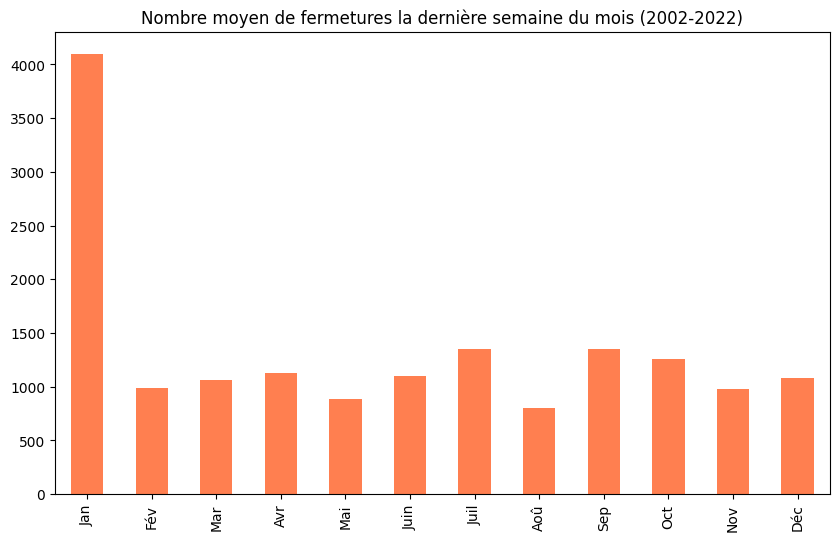

In [10]:
# 1. Préparation des dates
df['dateDebut'] = pd.to_datetime(df['dateDebut'], errors='coerce')

# 2. Filtrage global (2002 à 2022 + Fermetures uniquement)
df_periode = df[
    (df['dateDebut'].dt.year >= 2002) & 
    (df['dateDebut'].dt.year <= 2022) & 
    (df['etatAdministratifEtablissement'] == 'F')
].copy()

# 3. Filtrage de la première semaine du mois

# On ne garde que les dates qui tombent dans les 7 derniers jours du mois
df_derniere_semaine = df_periode[df_periode['dateDebut'].dt.day.isin(range(1,8))].copy()

# 4. Extraction du mois et de l'année
df_derniere_semaine['annee'] = df_derniere_semaine['dateDebut'].dt.year
df_derniere_semaine['mois'] = df_derniere_semaine['dateDebut'].dt.month

# 5. Calcul en deux étapes pour la rigueur statistique :
# Étape A : Comptage des fermetures (de la dernière semaine) pour chaque couple (Année, Mois)
# Ex: Combien en fin janv 2002, fin fév 2002, ..., fin janv 2003, etc.
comptage_par_annee_mois = df_derniere_semaine.groupby(['annee', 'mois']).size().reset_index(name='nb')

# Étape B : On agrège par mois de l'année
# Note : Utilisez .mean() pour la moyenne annuelle, ou .sum() pour le cumul total sur les 20 ans
resultat_par_mois = comptage_par_annee_mois.groupby('mois')['nb'].mean()

# Optionnel : Remplacer les numéros (1-12) par le nom des mois pour le graphique
noms_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
resultat_par_mois.index = noms_mois

# 6. Visualisation
plt.figure(figsize=(10, 6))
resultat_par_mois.plot(
    kind='bar', 
    color='coral',
    title='Nombre moyen de fermetures la dernière semaine du mois (2002-2022)'
)

### 4 Gestion des autoentrepreneurs

Au 1er janvier 2009, la loi concernant les autoentrepreneurs à créer une 'explosions' du nombre d'établissements créer pour certaines activités. On corrige ce biais en incluant uniquement les entreprises ayant 1 employé ou plus et on supprime celles qui n'en ont pas ou n'en ont jamais eu.

In [11]:
df = df[~df['trancheEffectifsEtablissement'].isin(['NN', '00', None])]

## Construction d'une base annualisée

On commence par modifier le DataFrame pour renseigner la date de création et de fermtures de chaque établissement

In [12]:
# 1. Sécurisation des formats : on s'assure que les colonnes d'origine sont bien des dates
df['dateCreationEtablissement'] = pd.to_datetime(df['dateCreationEtablissement'], errors='coerce')
df['dateDebut'] = pd.to_datetime(df['dateDebut'], errors='coerce')

# 2. Création de 'date_creation' (copie simple)
df['date_creation'] = df['dateCreationEtablissement']

# 3. Création de 'date_fermeture'
# On initialise la colonne avec des valeurs nulles (NaT = Not a Time)
df['date_fermeture'] = pd.NaT

# On remplit la date de fermeture avec 'dateDebut' UNIQUEMENT pour les établissements fermés ('F')
df.loc[df['etatAdministratifEtablissement'] == 'F', 'date_fermeture'] = df['dateDebut']

# Affichage des premières lignes pour vérifier le résultat
colonnes_a_verifier = ['siret', 'etatAdministratifEtablissement', 'date_creation', 'date_fermeture']
print(df[colonnes_a_verifier].head())

             siret etatAdministratifEtablissement date_creation date_fermeture
13  00554155200013                              A    1974-01-01            NaT
43  00578096000026                              A    1981-12-28            NaT
45  00578096000042                              A    1990-06-03            NaT
46  00578096000075                              A    2008-04-16            NaT
48  00578096000109                              A    2008-04-16            NaT


Comptabiliation des équipements par communes et par années 

Pour prendre en compte le surplus de fermetures chaque 1er janvier, on comptabilise les équipements de chaque années du 2 janvier au 1er janvier (inclus) de l'année suivante

In [13]:
df_prov = df.copy()

In [14]:
# S'assurer que les colonnes sont bien au format datetime (à faire une seule fois avant la boucle)
# Remplacez 'dateCreation' et 'dateFermeture' par les vrais noms de vos colonnes
df_prov['date_creation'] = pd.to_datetime(df_prov['date_creation'], errors='coerce')
df_prov['date_fermeture'] = pd.to_datetime(df_prov['date_fermeture'], errors='coerce')

resultats = []

# Boucle de comptage
for annee in range(2002, 2023):
    
    # Définition des bornes temporelles pour l'année en cours
    debut_periode = pd.Timestamp(f"{annee}-01-02")
    fin_periode = pd.Timestamp(f"{annee+1}-01-01")
    
    # Un établissement est compté s'il a été créé au plus tard à la fin de la période (1er janvier N+1)
    # ET qu'il a fermé strictement après le début de la période (2 janvier N), ou qu'il n'a pas de date de fermeture (NaT)
    masque = (
        (df_prov['date_creation'] <= fin_periode) & 
        ((df_prov['date_fermeture'] > debut_periode) | df_prov['date_fermeture'].isna())
    )
    
    temp = df_prov[masque].groupby(['codeCommuneEtablissement', 'activitePrincipaleEtablissement']).size().reset_index(name='nombre')
    temp['Annee'] = annee
    resultats.append(temp)
    
# Sécurité si la liste de résultats est vide
if not resultats:
    print("Aucun résultat trouvé pour ces paramètres.")
    
df_bpe_temporelle = pd.concat(resultats, ignore_index=True)

# Pivot pour obtenir le format BPE final
df_sirene = df_bpe_temporelle.pivot_table(
    index=['codeCommuneEtablissement', 'Annee'],
    columns='activitePrincipaleEtablissement',
    values='nombre',
    fill_value=0
).reset_index()

df_sirene.columns.name = None # Nettoyage esthétique

print("✅ Base générée avec succès !")

✅ Base générée avec succès !


Regroupement des catégories

Jusqu'ici, les établissements sont comptabilisée selon deux versions de la nomenclature NAF. On vient regrouper les établissements à l'aide d'une table de passage

In [15]:
# 1. Définition du dictionnaire de regroupement (Mapping + Libellés)
# Clé = Nouvel intitulé de colonne, Valeur = Liste des colonnes actuelles à sommer
regroupement = {
    # 55.1A (avec resto), 55.1C (sans resto), 55.1D (préfecture), 55.1E (auberges) sont devenus 55.10Z
    "Hôtels et hébergement": ["55.10Z", "55.1A", "55.1C", "55.1D", "55.1E"], 
    
    # 55.2C est devenu 55.30Z
    "Campings": ["55.30Z", "55.2C"],
    
    # 55.3A est devenu 56.10A
    "Restauration traditionnelle": ["56.10A", "55.3A"],
    
    # 55.4A (Cafés tabacs) et 55.4B (Débits de boissons) sont devenus 56.30Z
    "Débits de boissons": ["56.30Z", "55.4A", "55.4B"], 
    
    # 52.4L (livres) est devenu 47.61Z
    "Librairie": ["47.61Z", "52.4L"],
    
    # 52.4R (presse/papeterie) est devenu 47.62Z
    "Presse et papeterie": ["47.62Z", "52.4R"],
    
    # 92.3A (Activités artistiques) est devenu principalement 90.01Z
    "Arts du spectacle vivant": ["90.01Z", "92.3A"], 
    
    # 92.3B est devenu 90.02Z
    "Soutien au spectacle": ["90.02Z", "92.3B"],
    
    # 92.3D est devenu 90.04Z
    "Gestion de salles de spectacles": ["90.04Z", "92.3D"],
    
    # 90.03A et 90.03B (Création) n'avaient pas de code propre en 2003 (ils étaient noyés dans le 92.3A)
    "Création artistique (Autre)": ["90.03A", "90.03B"], 
    
    # 92.3H et 92.7C sont devenus 93.29Z
    "Activités récréatives et loisirs": ["93.29Z", "92.3H", "92.7C"],
    
    # 85.3K est devenu 88.10A
    "Aide à domicile": ["88.10A", "85.3K"],
    
    # 91.3E est devenu 94.99Z
    "Organisations associatives": ["94.99Z", "91.3E"]
}

# 2. Création des nouvelles colonnes sommées
# On ne prend que les colonnes qui existent réellement dans ton DF pour éviter les erreurs
for nom_final, colonnes_sources in regroupement.items():
    cols_presentes = [c for c in colonnes_sources if c in df_sirene.columns]
    if cols_presentes:
        df_sirene[nom_final] = df_sirene[cols_presentes].sum(axis=1)

# 3. Nettoyage : On ne garde que les colonnes d'identification et les nouveaux libellés
colonnes_id = ['codeCommuneEtablissement', 'Annee']
nouvelles_colonnes = list(regroupement.keys())

df_sirene = df_sirene[colonnes_id + nouvelles_colonnes].copy()


Visualisations graphiques par catégories

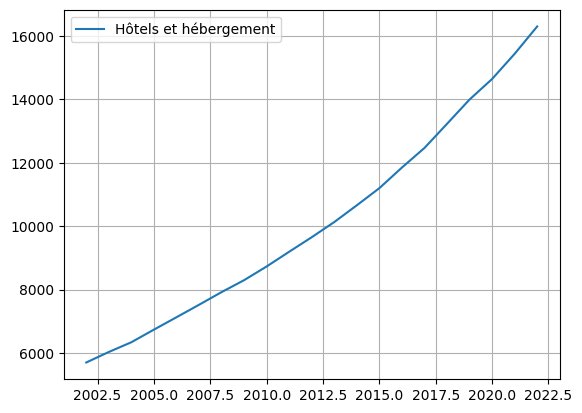

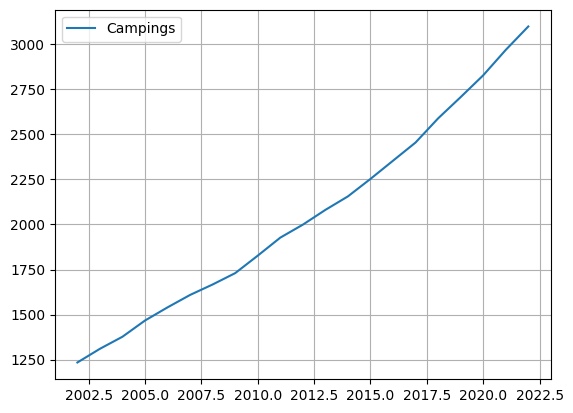

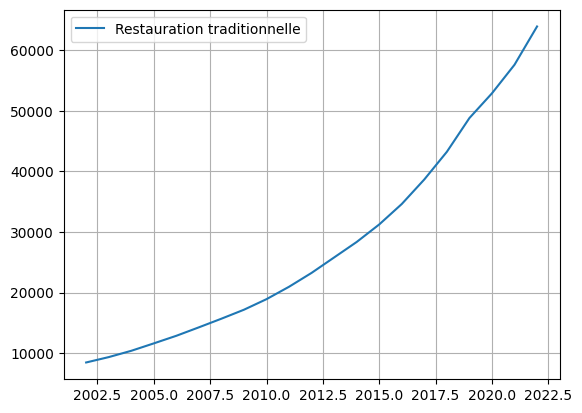

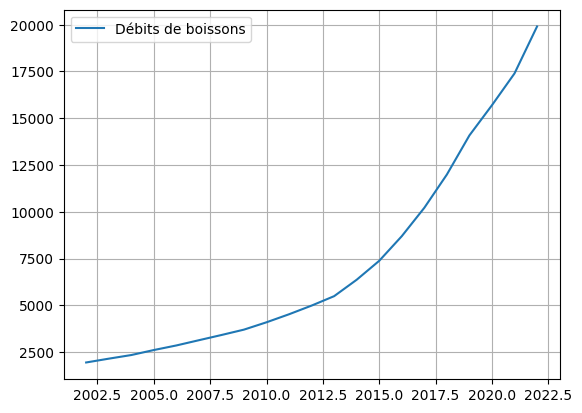

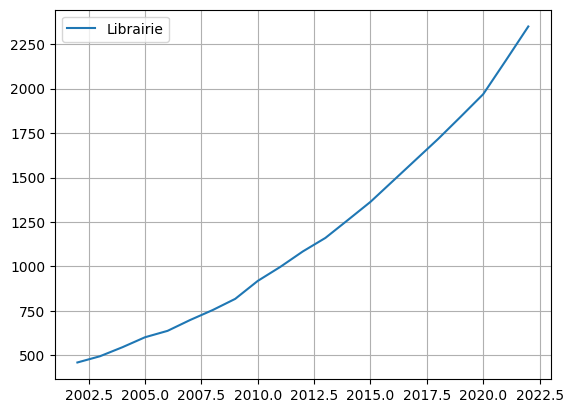

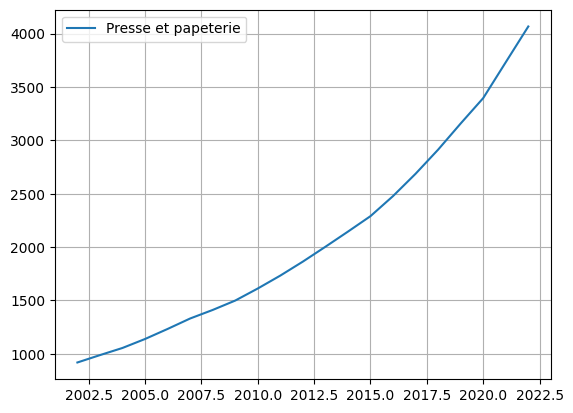

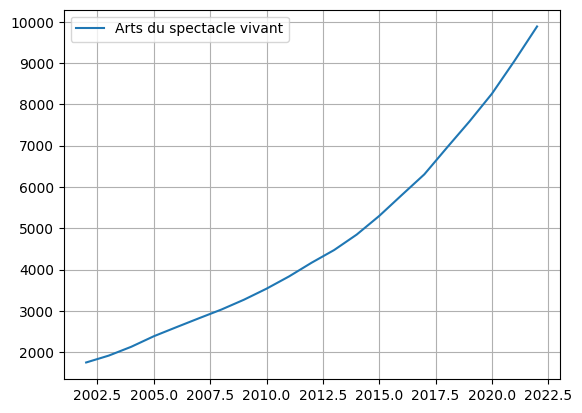

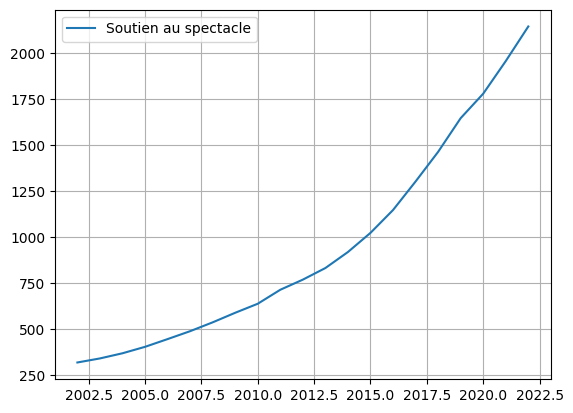

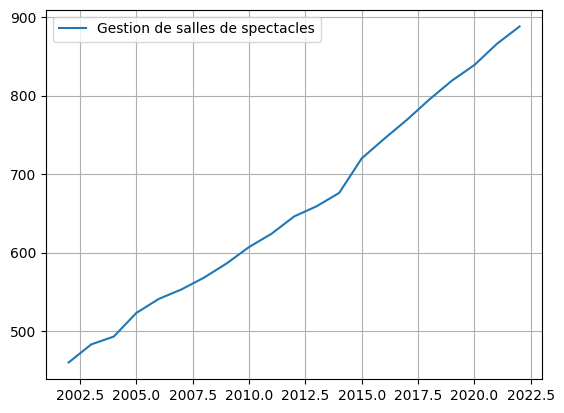

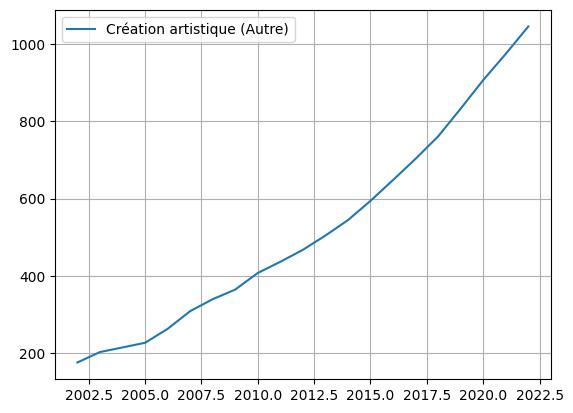

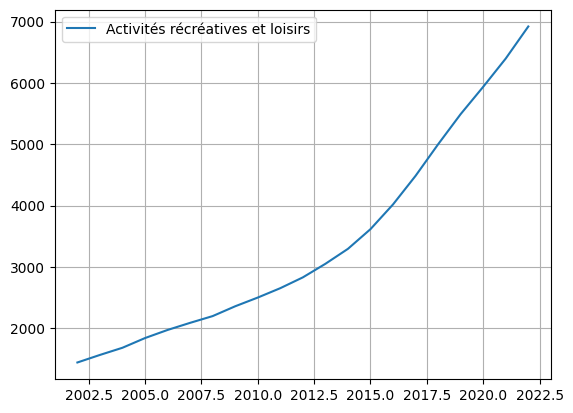

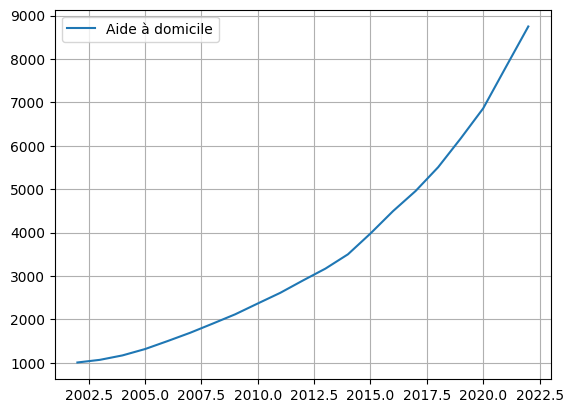

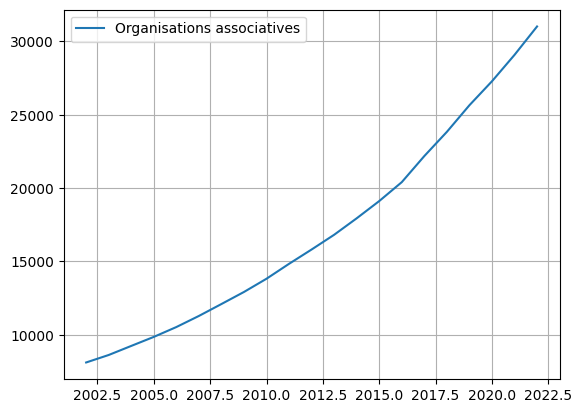

In [16]:
for code in df_sirene.columns[2:] :
    nb_etab = []

    for i in range (2002,2023) :
        nb_etab.append(df_sirene.loc[df_sirene['Annee']==i, code].sum())

    plt.plot(range (2002,2023), nb_etab, label=code)
    plt.grid()
    plt.legend()
    plt.show()

In [17]:
df_sirene.to_csv("Sirene_social.csv")